# BHD playground

Playing around with network creation and the bridge-hub detector algorithm.

In [1]:
import numpy as np   
import matplotlib.pyplot as plt
import networkx as nx

#EPIDEMIC ON NETWORKS 
#https://epidemicsonnetworks.readthedocs.io/en/latest/GettingStarted.html
#FROM the book 
#Mathematics of Epidemics on Networks: from Exact to Approximate Models
#István Z. KissJoel C. MillerPéter L. Simon
#Springer Link
import EoN

I never really worked with networkx but this is what EoN works with, which I think is the most convenient option for the SIR simulations. 

Let's just make a test network and play around a little to get familiar with it

In [2]:
# create a random test graph via SBM
# to have something with community structure
n = 1000
sizes = [200]* 5
p = np.outer(np.ones(len(sizes)), np.ones(len(sizes))) / n
p += np.diag([0.05]*len(sizes))
G_test = nx.stochastic_block_model(sizes, p)
# compute modularity
print("Modularity:", nx.algorithms.community.quality.modularity(G_test, nx.algorithms.community.label_propagation_communities(G_test)))

Modularity: 0.7252874903703703


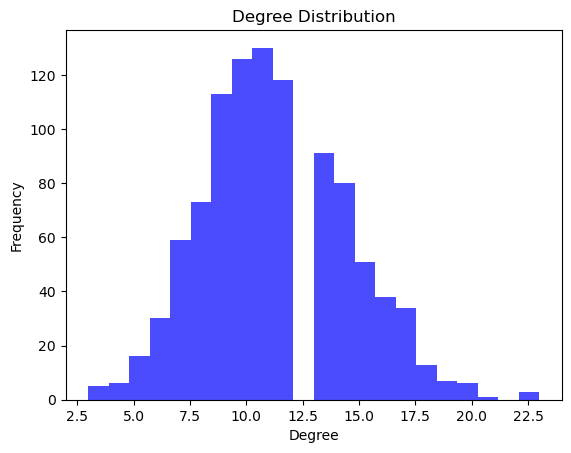

In [3]:
# plot degree distribution
degree_sequence = sorted([d for n, d in G_test.degree()], reverse=True) 
plt.hist(degree_sequence, bins=22, color='blue', alpha=0.7)
plt.title("Degree Distribution")    
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

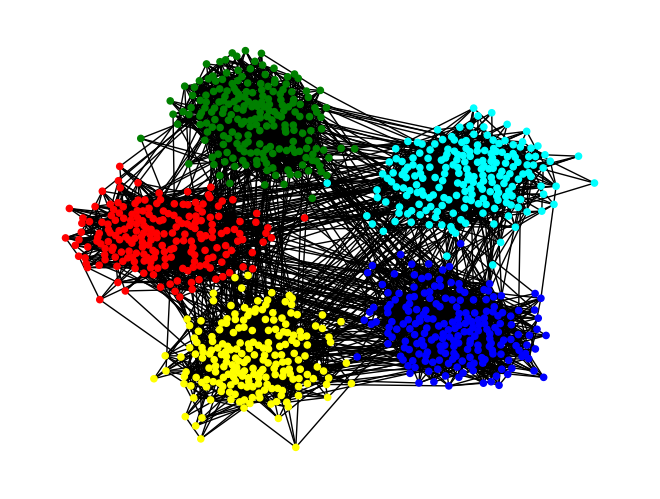

In [4]:
# visualise G and color nodes according to their block
# this is a super dumb way of doing it but oh well
color_map = []
for node in G_test.nodes():
    if node < 200:
        color_map.append('red')
    elif node < 400:
        color_map.append('blue')
    elif node < 600:
        color_map.append('green')
    elif node < 800:
        color_map.append('yellow')
    else:
        color_map.append('cyan')    
nx.draw(G_test, node_color=color_map, with_labels=False, node_size=20)
plt.show()

### BHD implementation
- Start self-avoiding random walk at random node $v_0$. After each step (past the 2nd one in the RW) do procedure
- $v_t$: RW node at step $t$, $f_t$: set of neighbours of $v_t$, $F_{t-1}= f_0 ∪ f_1 ∪ f_2 ∪ \dots  ∪ f_{t-1}$: Union of friendship circles/neighbours of all previously visited nodes
    - If every other node in $f_t$ already belongs to $F_{t-1}$ or at least has a link to it: $v_t$ not a target -> RW moves on
    - Else, at least one node in $f_t$ not connected to $F_{t-1}$: $v_t$ is immunization target; also random node of $f_t$ that cannot be linked back to $F_{t-1}$ is target -> new RW from random node
- Repeat until desired immunization ratio is achieved
- Terminate walks if no immunization targets found after 20 steps


In [5]:
def BHD(G, immunized_fraction=0.01, maxiter=1000, verbose=False):
    immunized_nodes = set()
    iterations = 0
    nodes = list(G.nodes())

    neighbor_cache = {}  # lazily populated as nodes are visited
    def get_neighbors(n):
        if n not in neighbor_cache:
            neighbor_cache[n] = set(G.neighbors(n))
        return neighbor_cache[n]

    while len(immunized_nodes) < immunized_fraction * G.number_of_nodes() and iterations < maxiter:
        iterations += 1
        RW = set() # nodes visited by the random walk
        F = set() # "friendship circle" (union of neighborhoods of visited nodes)

        # --- 2 steps to initialise the friendship circle ---
        # We just walk and accumulate F, no target checking yet
        node_curr = np.random.choice(nodes) # start at random node
        RW.add(node_curr) # add to RW set
        f_curr = get_neighbors(node_curr) # get neighbors of current node

        if verbose:
            print(f"\nIteration {iterations}: Starting node {node_curr}, neighbors {f_curr}")

        rw_options = f_curr - RW # options for self-avoiding continuation of the walk
        if not rw_options:
            if verbose:
                print(f"No options to continue from node {node_curr}. Restarting walk.")
            continue # if no options, start a new walk
        F.update(f_curr)  # add step 1 neighbourhood to F before moving to step 2
        node_curr = np.random.choice(list(rw_options)) # move to next node
        RW.add(node_curr) # add to RW set
        f_curr = get_neighbors(node_curr) # get neighbors

        if verbose:
            print(f"Step 2: Moved to node {node_curr}, neighbors {f_curr}")

        rw_options = f_curr - RW # options for self-avoiding continuation of the walk
        if not rw_options:
            if verbose:
                print(f"No options to continue from node {node_curr}. Restarting walk.")
            continue # if no options, start a new walk
        F.update(f_curr)  # add step 2 neighbourhood to F before moving to step 3
        node_curr = np.random.choice(list(rw_options)) # move to next node
        RW.add(node_curr) # add to RW set

        # --- Main walk: check for immunization targets ---
        # At this point F contains neighbourhoods of steps 1 and 2,
        # and node_curr is at step 3 — ready for the first check
        restart = False
        while len(RW) < 20 and not restart:
            f_curr = get_neighbors(node_curr) # get neighbors of current node
    
            # Compare f_curr against F_{t-1} (F does NOT yet contain f_curr)
            candidate_nodes = f_curr.difference(F) # candidates are neighbours not yet in the circle F
            immunization_targets = {
                c for c in candidate_nodes # go through candidates
                if not get_neighbors(c).difference({node_curr}).intersection(F) # check if candidate links back to F
            }

            if verbose:
                print(f"At node {node_curr}, neighbors {f_curr}, friendship circle F {F}")
                print(f"Candidate nodes for immunization: {candidate_nodes}")
                print(f"Immunization targets (candidates with no links back to F): {immunization_targets}")

            if immunization_targets: # if we found targets
                immunized_nodes.add(node_curr) # immunize current node
                immunized_nodes.add(np.random.choice(list(immunization_targets))) # immunize random neighbour that doesn't link back
                restart = True # we found a target, so we restart the walk
                if verbose:
                    print(f"Immunized node {node_curr} and target {immunization_targets}. Restarting walk.")
            else:
                if verbose:
                    print(f"No immunization targets found at node {node_curr}. Continuing walk.")
                # Only now add f_curr to F, then advance the walk
                rw_options = f_curr - RW # check for self-avoiding walk options
                if not rw_options:
                    restart = True # if no options, we restart the walk
                    if verbose:
                        print(f"No options to continue from node {node_curr}. Restarting walk.")
                else:
                    F.update(f_curr)  # update circle with current neighbors before moving to next node
                    node_curr = np.random.choice(list(rw_options)) # move to next node
                    RW.add(node_curr) # add to RW set

    if verbose:
        if iterations >= maxiter:
            print(f"\nReached maximum iterations ({maxiter}) without immunizing the desired fraction of nodes. Immunized nodes: {immunized_nodes}")
        else:
            print(f"\nFinished after {iterations} iterations. Immunized nodes: {immunized_nodes}")  
    return immunized_nodes


Iteration 1: Starting node A1, neighbors {'A4', 'A3', 'A2', 'A5'}
Step 2: Moved to node A4, neighbors {'A5', 'A3', 'A2', 'A1'}
At node A2, neighbors {'A5', 'A3', 'A4', 'A1'}, friendship circle F {'A3', 'A5', 'A4', 'A1', 'A2'}
Candidate nodes for immunization: set()
Immunization targets (candidates with no links back to F): set()
No immunization targets found at node A2. Continuing walk.
At node A3, neighbors {'A5', 'A4', 'A1', 'B', 'A2'}, friendship circle F {'A3', 'A5', 'A4', 'A1', 'A2'}
Candidate nodes for immunization: {'B'}
Immunization targets (candidates with no links back to F): {'B'}
Immunized node A3 and target {'B'}. Restarting walk.

Finished after 1 iterations. Immunized nodes: {np.str_('A3'), np.str_('B')}
Immunized: {np.str_('A3'), np.str_('B')}


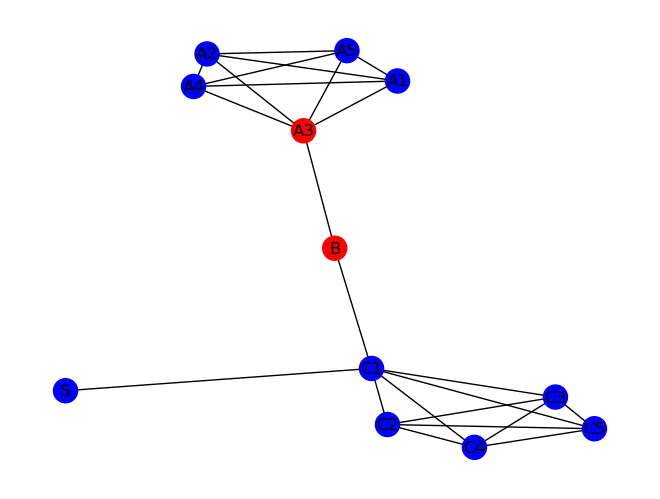

In [6]:
#let's make a test graph where we know for sure what should happen
G = nx.Graph()
# Community 1: dense clique of 5 nodes
community1 = ["A1", "A2", "A3", "A4", "A5"]
for i in range(len(community1)):
    for j in range(i+1, len(community1)):
        G.add_edge(community1[i], community1[j])
# Community 2: dense clique of 5 nodes
community2 = ["C1", "C2", "C3", "C4", "C5"]
for i in range(len(community2)):
    for j in range(i+1, len(community2)):
        G.add_edge(community2[i], community2[j])
# Bridge-hub node B: connects the two communities
# B's neighbourhood spans both cliques, so nodes on opposite sides
# have no links to each other - which means BHD should find it
G.add_edge("B", "A3")   # connects into community 1
G.add_edge("B", "C1")   # connects into community 2

# Satellite node S: connected only to C1, no link to B's friendship circle
# This makes S a valid immunization target when the walk is near B
G.add_edge("S", "C1")

# Run BHD — with 12 nodes, immunized_fraction=0.1 means we need ~1-2 nodes
immunized = BHD(G, immunized_fraction=0.1, maxiter=20, verbose=True)
print("Immunized:", immunized)
# Expected: B should appear, and one of {A-nodes, C-nodes, or S} as the satellite target
color_map = []
for node in G.nodes():
    if node in immunized:
        color_map.append('red')
    else:
        color_map.append('blue')
nx.draw(G, node_color=color_map, with_labels=True, node_size=300)
plt.show()

Yay! Let's do another test on something marginally bigger:

Immunized nodes: {np.int64(0), np.int64(35), np.int64(8), np.int64(9), np.int64(75), np.int64(47), np.int64(82), np.int64(88), np.int64(56), np.int64(62)}


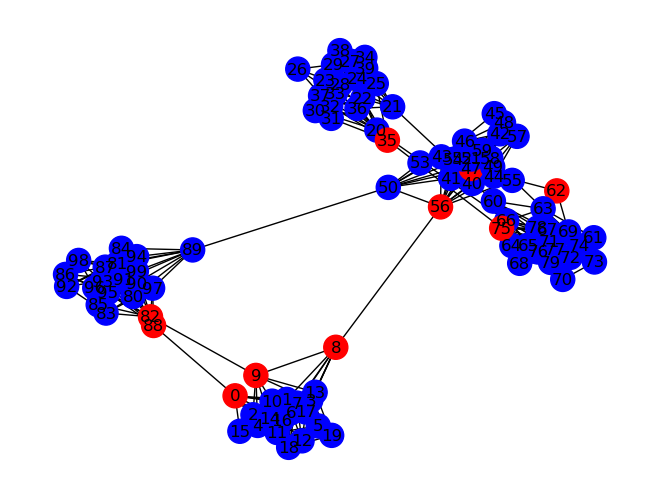

In [7]:
# make a tiny SBM graph and test BHD on it
n = 100
sizes = [20]* 5
p = np.outer(np.ones(len(sizes)), np.ones(len(sizes))) / (4*n)
p += np.diag([0.4]*len(sizes))
G = nx.stochastic_block_model(sizes, p)

immunized_nodes = BHD(G, immunized_fraction=0.1) 
print("Immunized nodes:", immunized_nodes)

# visualise G and highlight immunized nodes
color_map = []
for node in G.nodes():
    if node in immunized_nodes:
        color_map.append('red')
    else:
        color_map.append('blue')
nx.draw(G, node_color=color_map, with_labels=True, node_size=300)
plt.show()

Now let's try with the Graph from the beginning, and run an SIR simulation as well (using the Epidemics on Networks library)!

In [8]:
tmax = 100 # maximum time for SIR simulation
beta = 0.12 #infection/transmission rate
gamma = 0.2 #recovery rate
#rho = 1/n      #random fraction initially infected, which doesn't work together with initial recovereds though???
immunized_fraction = 0.005
immunized_nodes = BHD(G_test, immunized_fraction=immunized_fraction)

#run SIR simulation
results = EoN.fast_SIR(G_test, beta, gamma, tmax=tmax, initial_recovereds=immunized_nodes, return_full_data = True)

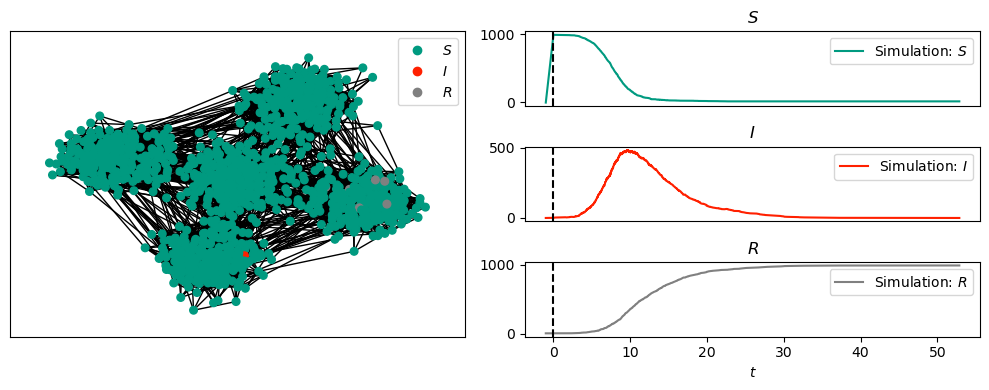

In [9]:
results.display(0, node_size=30) # this is very convenient, nice
plt.show()

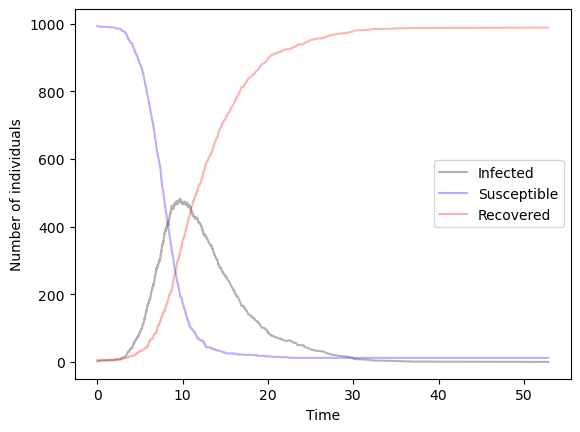

In [10]:
t, S, I, R = results.t(), results.S(), results.I(), results.R()
plt.plot(t[1:], I[1:], color = 'k', alpha=0.3, label='Infected')
plt.plot(t[1:], S[1:], color = 'b', alpha=0.3, label='Susceptible')
plt.plot(t[1:], R[1:], color = 'r', alpha=0.3, label='Recovered')
plt.xlabel('Time')
plt.ylabel('Number of individuals')
plt.legend()
plt.show()

### ACQ
Just for the funsies, this shouldn't be too hard either!

In [11]:
def ACQ(G, immunized_fraction=0.01, n=2):
    #acquaintance immunization (ACQ): (Cohen et al.)
    #  random node -> random acquaintance of node 
    # -> immunize node if acquaintance at least n(=1, 2) times;
    nodes = list(G.nodes())
    acquaintance_counts = {node: 0 for node in nodes} # count how many times each node is chosen as an acquaintance

    immunized_nodes = set()
    while len(immunized_nodes) < immunized_fraction * G.number_of_nodes():
        node = np.random.choice(nodes)
        neighbors = list(G.neighbors(node))
        if not neighbors:
            continue # skip isolated nodes
        acquaintance = np.random.choice(neighbors)
        acquaintance_counts[acquaintance] += 1
        if acquaintance_counts[acquaintance] >= n:
            immunized_nodes.add(node) # immunize the original node if acquaintance is already immunized

    return immunized_nodes

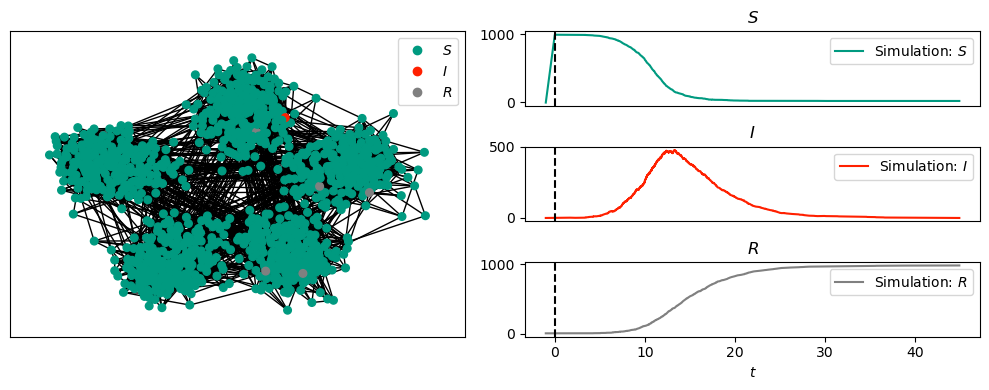

In [12]:
immunized_nodes = ACQ(G_test, immunized_fraction=immunized_fraction, n=2)

#run SIR simulation
results = EoN.fast_SIR(G_test, beta, gamma, tmax=tmax, initial_recovereds=immunized_nodes, return_full_data = True)
results.display(0, node_size=30) 
plt.show()

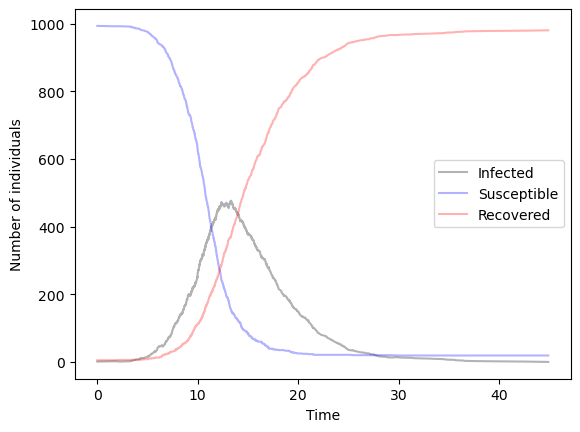

In [13]:
t, S, I, R = results.t(), results.S(), results.I(), results.R()
plt.plot(t[1:], I[1:], color = 'k', alpha=0.3, label='Infected')
plt.plot(t[1:], S[1:], color = 'b', alpha=0.3, label='Susceptible')
plt.plot(t[1:], R[1:], color = 'r', alpha=0.3, label='Recovered')
plt.xlabel('Time')
plt.ylabel('Number of individuals')
plt.legend()
plt.show()

### BNI-LI
Because how hard could it be, really?

In [14]:
def BNI_LI(G, immunized_fraction=0.01, maxiter=1000, verbose=False):
    immunized_nodes = set()
    # for now, a placeholder
    # but just you wait :D
    return immunized_nodes